# Chapter 15: Моделирование последовательных данных с помощью рекуррентных неиронных сетей (Часть 3)

In [1]:
from IPython.display import Image
%matplotlib inline

## 15.3.2. Проект № 2:  моделирование языка на уровне символов в PyTorch

Языковое моделирование - увлекательное применение для нейронных сетей, позво­ляющее машинам выполнять задачи, связанные с человеческим языком, - например, генерировать предложения на естественном языке. В модели, которую мы сейчас построим, входными данными является текстовый доку­мент, и наша цель - разработать модель, которая может генерировать новый текст, похожий по стилю на входной документ. Примерами ввода для такой модели могут 
служить книга или компьютерная программа на каком-либо языке программирования. В языковом моделировании на уровне символов ввод разбивается на последователь­ность символов, которые вводятся в нашу сеть по одному символу за раз. Сеть будет обрабатывать каждый новый символ в сочетании с памятью о ранее увиденных симво­лах, чтобы предсказать следующий. 

На рис. 15.11 показан пример моделирования языка на уровне символов (EOS  здесь означает end of sequence, т. е. «конец последовательности»). 

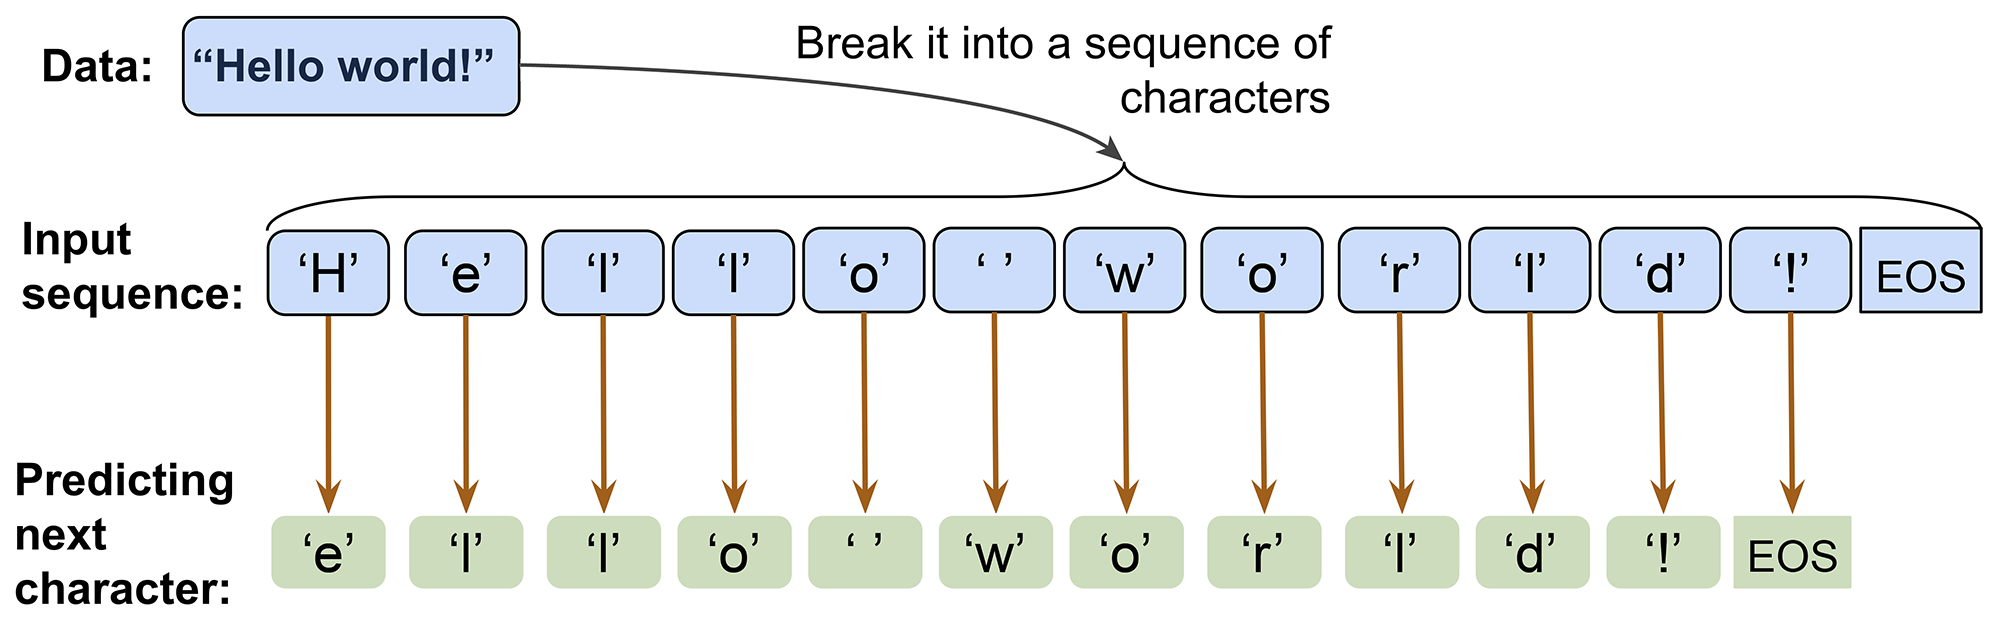

In [3]:
Image(filename='figures/15_11.png', width=600)

Мы можем разбить решение этой задачи на три отдельных этапа: подготовка данных, построение модели RNN  и выполнение предсказания следующего символа, а также вы­борки для создания нового текста.

### Предварительная обработка набора данных

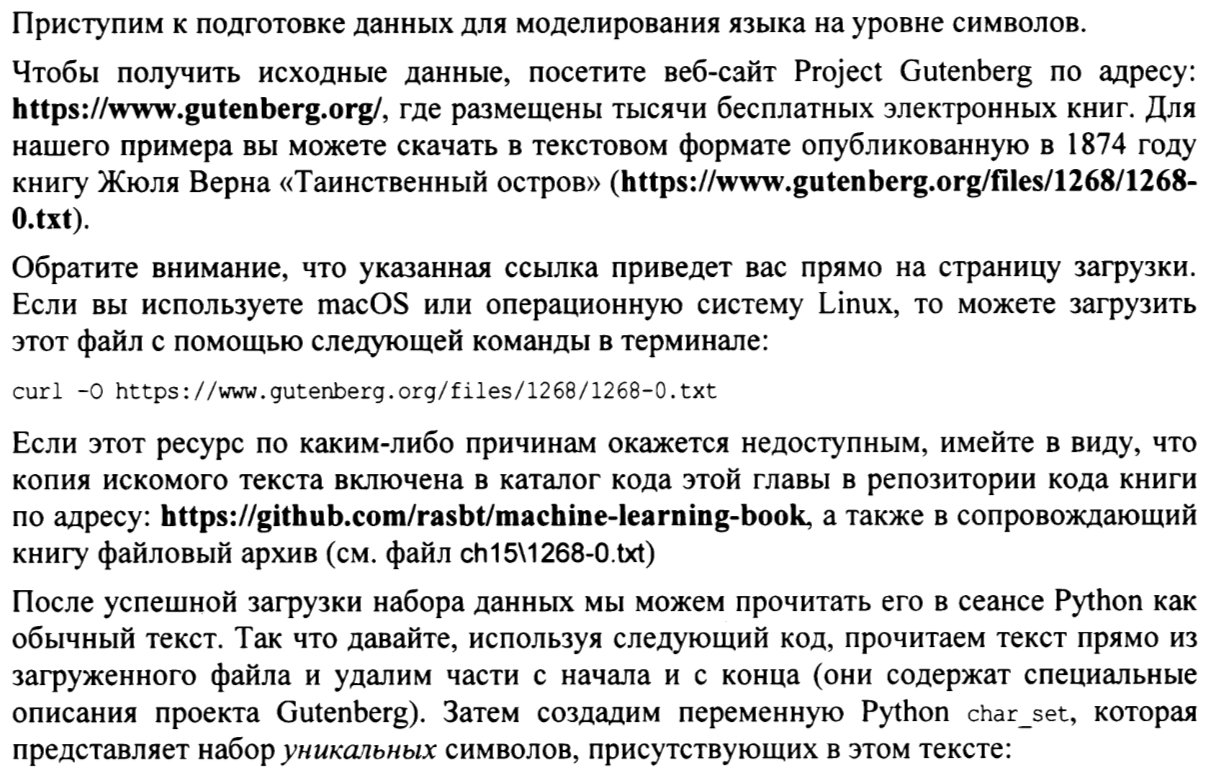

In [5]:
Image(filename='figures/text3.png', width=600)

In [6]:
import numpy as np

# Чтение и nредварительная обработка текста
with open('1268-0.txt', 'r', encoding="utf8") as fp:
    text=fp.read()
    
start_indx = text.find('THE MYSTERIOUS ISLAND')
end_indx = text.find('End of the Project Gutenberg')

text = text[start_indx:end_indx]
char_set = set(text)
print('Oбщaя длина:', len(text))
print('Уникальных символов:', len(char_set))

Oбщaя длина: 1112350
Уникальных символов: 80


После загрузки и предварительной обработки текста мы получим последовательность общей длиной 1112350  символов, состоящую из 80 уникальных символов. Однако большинство нейросетевых библиотек и реализаций RNN  не могут работать со вход­ными данными в строковом формате, поэтому нам приходится преобразовывать текст в числовой формат. Для этого мы создадим простой словарь Python char2int,  который сопоставляет каждый символ с целым числом. Нам также понадобится обратное сопос­тавление, чтобы преобразовать вывод нашей модели обратно в текст. Хотя обратное сопоставление можно сделать с помощью словаря, который связывает целочисленные ключи со значениями символов, использование массива NumPy  и индексация массива для сопоставления индексов с этими уникальными символами более эффективны. На рис. 15.12  приведен пример преобразования символов в целые числа и наоборот для 
слов «Hello»  и «world»: 

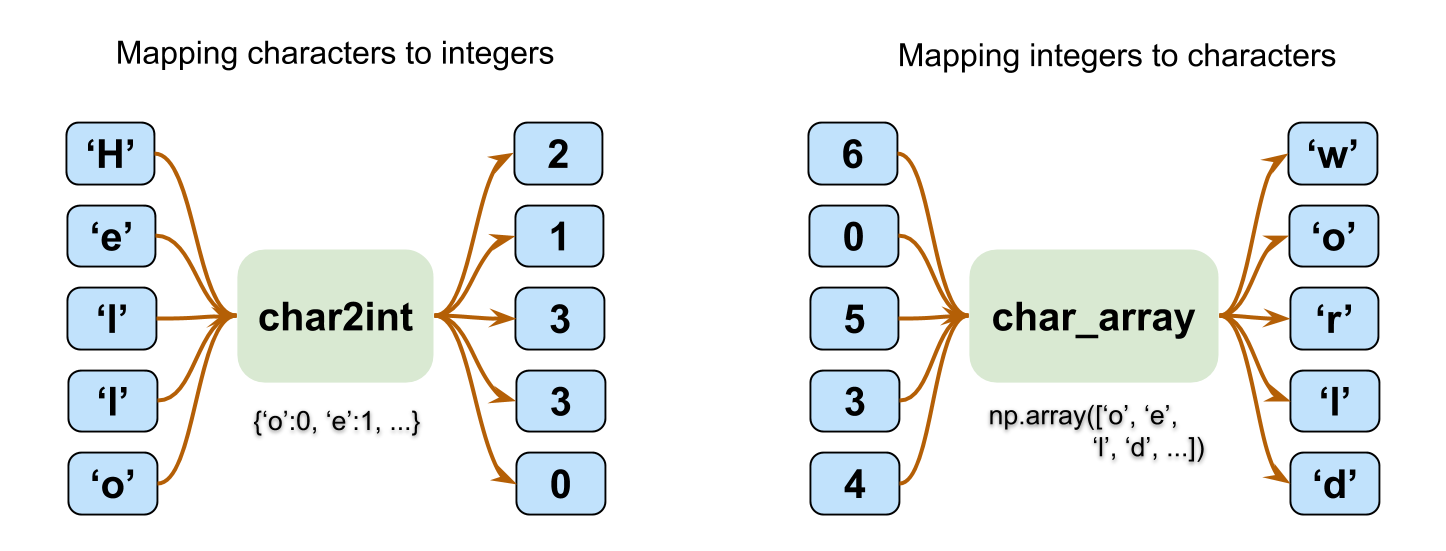

In [7]:
Image(filename='figures/15_12.png', width=600)

Построение словаря для сопоставления символов с целыми числами и обратное сопос­тавление посредством индексации массива NumPy,  показанное на рис. 15.12,  выглядит следующим образом: 

In [8]:
chars_sorted = sorted(char_set)
char2int = {ch:i for i,ch in enumerate(chars_sorted)}
char_array = np.array(chars_sorted)

text_encoded = np.array([char2int[ch] for ch in text],dtype=np.int32)

print('Рaзмep закодированного текста: ', text_encoded.shape)

print(text[:15], '     == Кодирование ==> ', text_encoded[:15])
print(text_encoded[15:21], ' == Декодирование  ==> ', ''.join(char_array[text_encoded[15:21]]))

Рaзмep закодированного текста:  (1112350,)
THE MYSTERIOUS       == Кодирование ==>  [44 32 29  1 37 48 43 44 29 42 33 39 45 43  1]
[33 43 36 25 38 28]  == Декодирование  ==>  ISLAND


Массив NumPy  text_encoded содержит закодированные значения для  всех символов в тексте. Выведем сопоставления первых пяти символов из этого массива:

In [9]:
for ex in text_encoded[:5]:
    print('{} -> {}'.format(ex, char_array[ex]))

44 -> T
32 -> H
29 -> E
1 ->  
37 -> M


Теперь давайте отступим на шаг назад и посмотрим на общую картину того, что мы пытаемся сделать. Что касается задачи генерации текста, то ее можно сформулировать как задачу классификации.

Предположим, у нас есть набор неполных последовательностей текстовых символов, как показано на рис. 15. 13. 

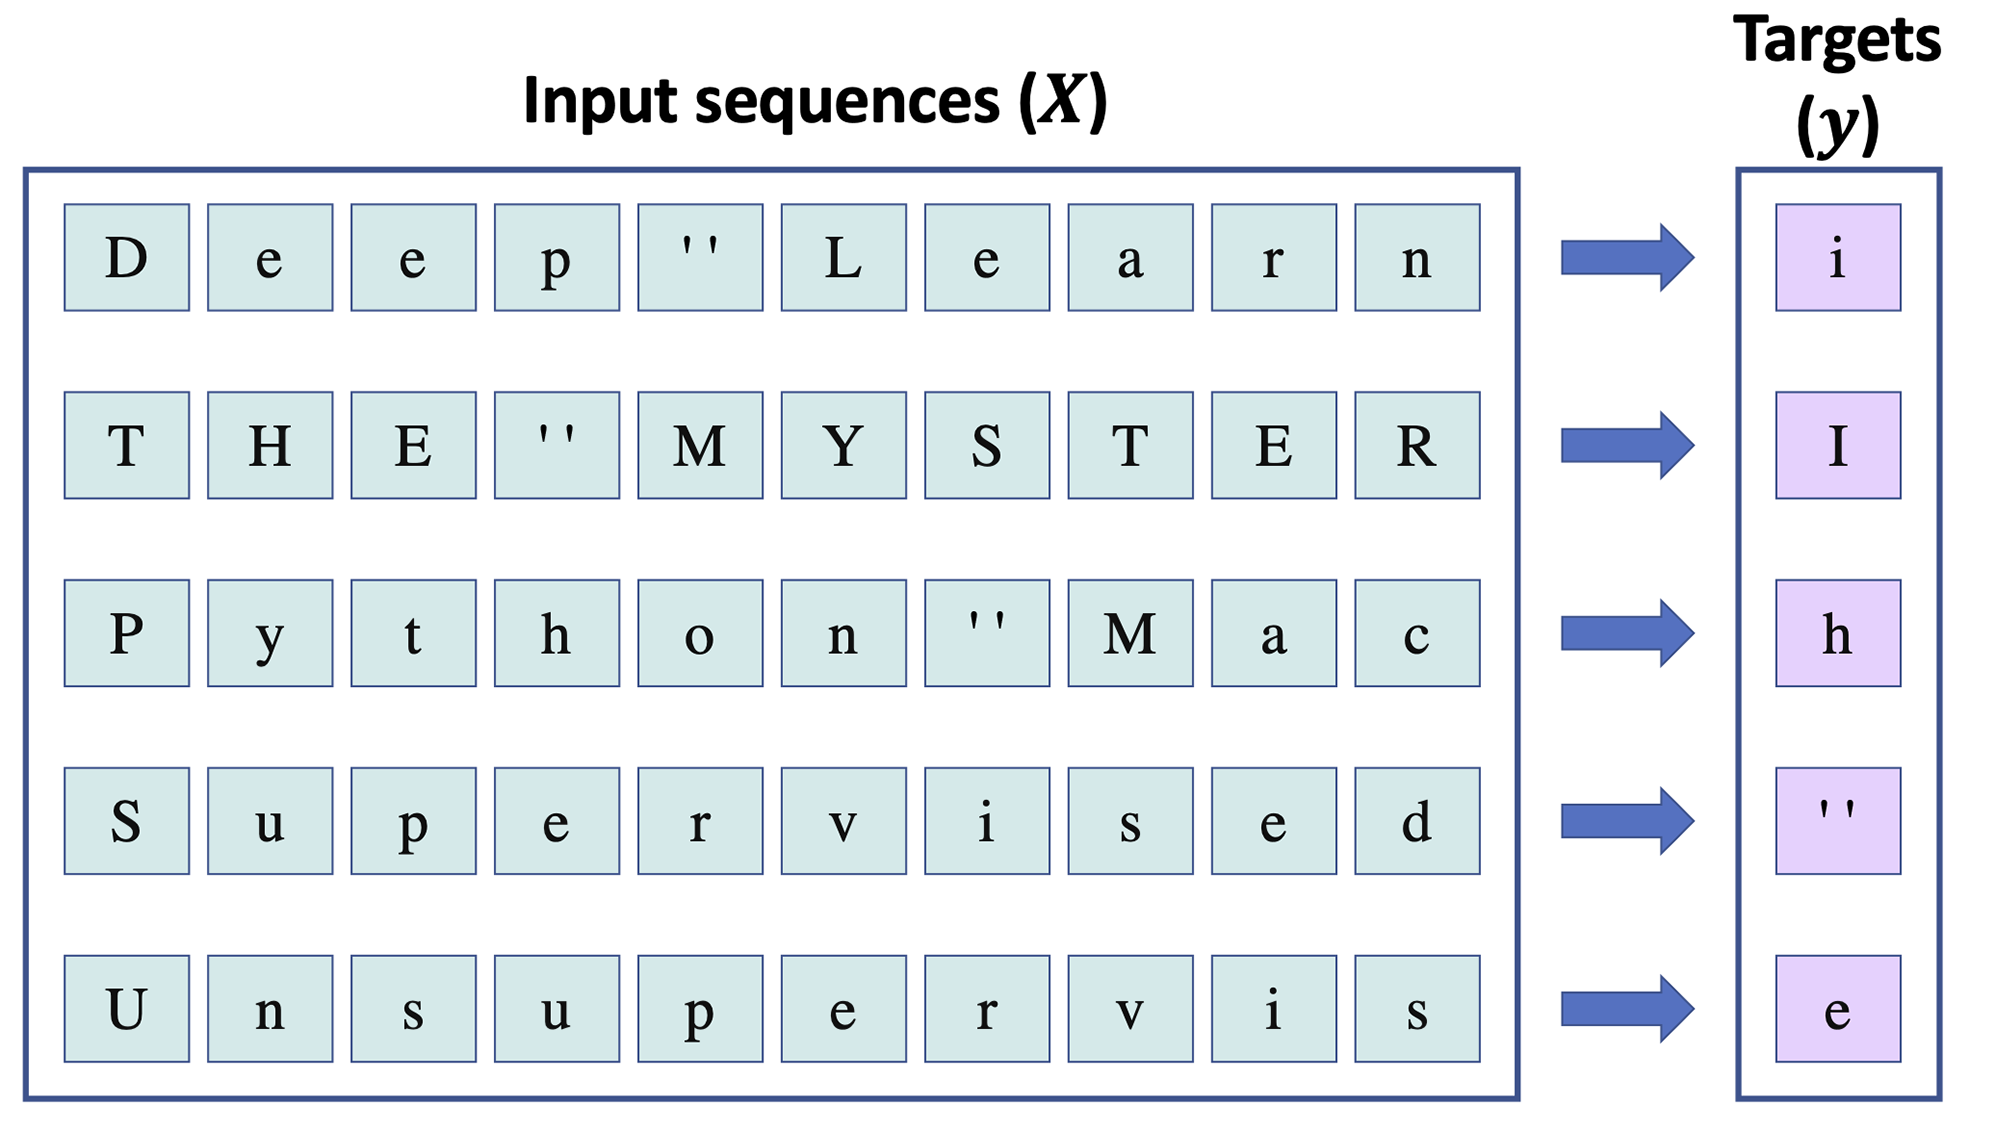

In [ ]:
Image(filename='figures/15_13.png', width=600)

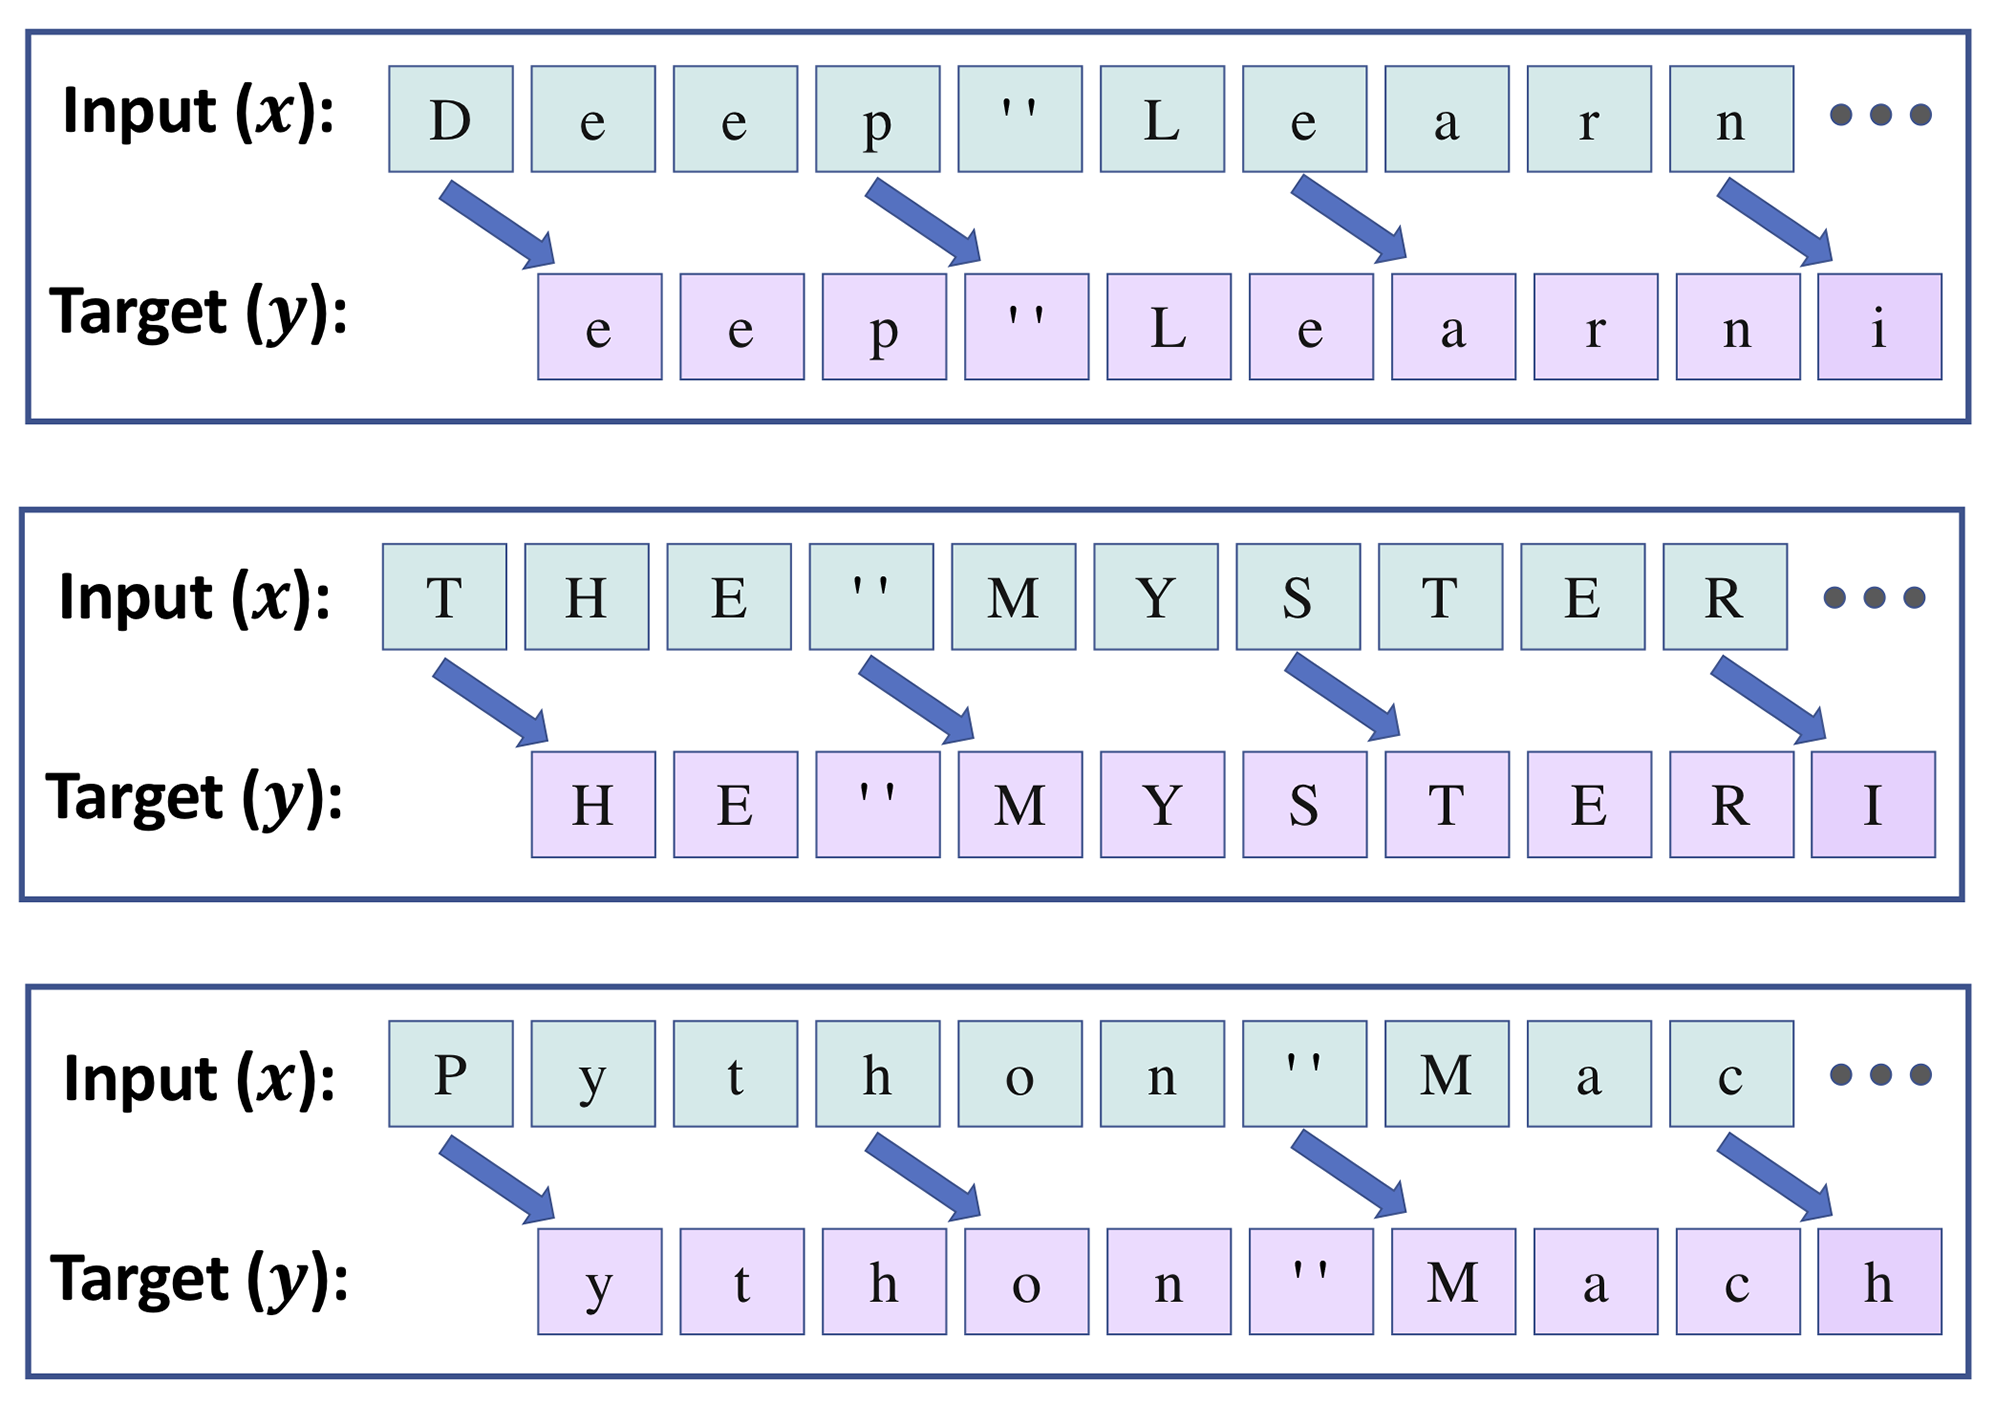

In [10]:
Image(filename='figures/15_14.png', width=500)

In [17]:
seq_length = 40
chunk_size = seq_length + 1

text_chunks = [text_encoded[i:i+chunk_size] for i in range(len(text_encoded)-chunk_size+1)] 

## inspection:
for seq in text_chunks[:1]:
    input_seq = seq[:seq_length]
    target = seq[seq_length] 
    print(input_seq, ' -> ', target)
    print(repr(''.join(char_array[input_seq])), 
          ' -> ', repr(''.join(char_array[target])))

[44 32 29  1 37 48 43 44 29 42 33 39 45 43  1 33 43 36 25 38 28  1  6  6
  6  0  0  0  0  0 40 67 64 53 70 52 54 53  1 51]  ->  74
'THE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced b'  ->  'y'


In [18]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, text_chunks):
        self.text_chunks = text_chunks

    def __len__(self):
        return len(self.text_chunks)
    
    def __getitem__(self, idx):
        text_chunk = self.text_chunks[idx]
        return text_chunk[:-1].long(), text_chunk[1:].long()
    
seq_dataset = TextDataset(torch.tensor(text_chunks))

In [19]:
for i, (seq, target) in enumerate(seq_dataset):
    print(' Input (x):', repr(''.join(char_array[seq])))
    print('Target (y):', repr(''.join(char_array[target])))
    print()
    if i == 1:
        break

 Input (x): 'THE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced b'
Target (y): 'HE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced by'

 Input (x): 'HE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced by'
Target (y): 'E MYSTERIOUS ISLAND ***\n\n\n\n\nProduced by '



In [20]:
device = torch.device("cuda:0")
# device = 'cpu'

Наконец, последний шаг в подготовке набора данных - преобразовать этот набор дан­ных в мини-пакеты: 

In [21]:
from torch.utils.data import DataLoader
 
batch_size = 64

torch.manual_seed(1)
seq_dl = DataLoader(seq_dataset, batch_size=batch_size, shuffle=True, drop_last=True)


### Построение модели RNN  символьного уровня

In [22]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, rnn_hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) 
        self.rnn_hidden_size = rnn_hidden_size
        self.rnn = nn.LSTM(embed_dim, rnn_hidden_size, 
                           batch_first=True)
        self.fc = nn.Linear(rnn_hidden_size, vocab_size)

    def forward(self, x, hidden, cell):
        out = self.embedding(x).unsqueeze(1)
        out, (hidden, cell) = self.rnn(out, (hidden, cell))
        out = self.fc(out).reshape(out.size(0), -1)
        return out, hidden, cell

    def init_hidden(self, batch_size):
        hidden = torch.zeros(1, batch_size, self.rnn_hidden_size)
        cell = torch.zeros(1, batch_size, self.rnn_hidden_size)
        return hidden.to(device), cell.to(device)
    
vocab_size = len(char_array)
embed_dim = 256
rnn_hidden_size = 512

torch.manual_seed(1)
model = RNN(vocab_size, embed_dim, rnn_hidden_size) 
model = model.to(device)
model

RNN(
  (embedding): Embedding(80, 256)
  (rnn): LSTM(256, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=80, bias=True)
)

In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

num_epochs = 10000 

torch.manual_seed(1)

for epoch in range(num_epochs):
    hidden, cell = model.init_hidden(batch_size)
    seq_batch, target_batch = next(iter(seq_dl))
    seq_batch = seq_batch.to(device)
    target_batch = target_batch.to(device)
    optimizer.zero_grad()
    loss = 0
    for c in range(seq_length):
        pred, hidden, cell = model(seq_batch[:, c], hidden, cell) 
        loss += loss_fn(pred, target_batch[:, c])
    loss.backward()
    optimizer.step()
    loss = loss.item()/seq_length
    if epoch % 500 == 0:
        print(f'Epoch {epoch} loss: {loss:.4f}')
 

Epoch 0 loss: 4.3722
Epoch 500 loss: 1.4087
Epoch 1000 loss: 1.3545
Epoch 1500 loss: 1.2213
Epoch 2000 loss: 1.2359
Epoch 2500 loss: 1.2025
Epoch 3000 loss: 1.1546
Epoch 3500 loss: 1.1433
Epoch 4000 loss: 1.1859
Epoch 4500 loss: 1.1597
Epoch 5000 loss: 1.1012
Epoch 5500 loss: 1.1212
Epoch 6000 loss: 1.1437
Epoch 6500 loss: 1.1226
Epoch 7000 loss: 1.1262
Epoch 7500 loss: 1.1744
Epoch 8000 loss: 1.1254
Epoch 8500 loss: 1.1644
Epoch 9000 loss: 1.1111
Epoch 9500 loss: 1.1140


### Этап оценки: создание новых отрывков текста

In [24]:
from torch.distributions.categorical import Categorical

torch.manual_seed(1)

logits = torch.tensor([[1.0, 1.0, 1.0]])

print('Probabilities:', nn.functional.softmax(logits, dim=1).numpy()[0])

m = Categorical(logits=logits)
samples = m.sample((10,))
 
print(samples.numpy())

Probabilities: [0.33333334 0.33333334 0.33333334]
[[0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [2]
 [1]
 [1]]


In [25]:
torch.manual_seed(1)

logits = torch.tensor([[1.0, 1.0, 3.0]])

print('Probabilities:', nn.functional.softmax(logits, dim=1).numpy()[0])

m = Categorical(logits=logits)
samples = m.sample((10,))
 
print(samples.numpy())

Probabilities: [0.10650698 0.10650698 0.78698605]
[[0]
 [2]
 [2]
 [1]
 [2]
 [1]
 [2]
 [2]
 [2]
 [2]]


In [26]:
def sample(model, starting_str, 
           len_generated_text=500, 
           scale_factor=1.0):

    encoded_input = torch.tensor([char2int[s] for s in starting_str])
    encoded_input = torch.reshape(encoded_input, (1, -1))

    generated_str = starting_str

    model.eval()
    hidden, cell = model.init_hidden(1)
    hidden = hidden.to('cpu')
    cell = cell.to('cpu')
    for c in range(len(starting_str)-1):
        _, hidden, cell = model(encoded_input[:, c].view(1), hidden, cell) 
    
    last_char = encoded_input[:, -1]
    for i in range(len_generated_text):
        logits, hidden, cell = model(last_char.view(1), hidden, cell) 
        logits = torch.squeeze(logits, 0)
        scaled_logits = logits * scale_factor
        m = Categorical(logits=scaled_logits)
        last_char = m.sample()
        generated_str += str(char_array[last_char])
        
    return generated_str

torch.manual_seed(1)
model.to('cpu')
print(sample(model, starting_str='The island'))

The island would discover
us the western shore, but four-does the case which did not hold reach the report is a bone.

Where,” replied Gideon Spilett, “we went back down to Harding, I asoeve time to as
on the elemenas, where frequent themselves in the boat,
and plas waters of the mountain. The direction in a choil, and agility, to be doubles, and a large hurrier woods and drifted from
the water’s heart, who, and the dygan, Top said he drew off, after allowed the windows and them for it with the entralianc


* **Predictability vs. randomness**

In [27]:
logits = torch.tensor([[1.0, 1.0, 3.0]])

print('Probabilities before scaling:        ', nn.functional.softmax(logits, dim=1).numpy()[0])

print('Probabilities after scaling with 0.5:', nn.functional.softmax(0.5*logits, dim=1).numpy()[0])

print('Probabilities after scaling with 0.1:', nn.functional.softmax(0.1*logits, dim=1).numpy()[0])


Probabilities before scaling:         [0.10650698 0.10650698 0.78698605]
Probabilities after scaling with 0.5: [0.21194156 0.21194156 0.57611686]
Probabilities after scaling with 0.1: [0.3104238  0.3104238  0.37915248]


In [28]:
torch.manual_seed(1)
print(sample(model, starting_str='The island', 
             scale_factor=2.0))

The island was the convicts would be confidence, and the best six course, and the sailor and Herbert and Herbert and Herbert’s continued to the plateau, and the sailor thought that the soil, the convicts the meat of the sailor.

“But who, a shot was starbed a single stores of the mountain, and then agreed that the last and stores of the river’s most common containing the plan was finding the corral, which he and Herbert was not a sandy species of the island and which is a shore, and it was the beach, the 


In [29]:
torch.manual_seed(1)
print(sample(model, starting_str='The island', 
             scale_factor=0.5))

The island

scited
magniTe
zlaged to be fulling,-- crowno, ends, flabila, a tuovels filleds aboundoed; I hope
aidfuffiel he anveded?
As to hod quarter only edubblingd catlue, Cyrus was soon, Picired as
if
thume!’”’
esides, 5
fre lky of ourse, by
recalyas,’,
a rig?
No! Chapter the replakfy. Towards harness Nacabon without
imagear-pubreenky,” “onamPom, ammunies on wools advancipul’!
He,
salt pet!

Where!”

However, the yea-RaTly Jucklief unperfeciessatiariza-distance?”

“The gui-mackluin was staired veminab



...


# Summary

...


В этой главе вы сначала узнали о характерных свойствах последовательностей, отли­чающих их от других типов данных, таких как структурированные данные или изобра­жения. Затем мы рассмотрели основы RNN  для моделирования последовательностей. Вы также познакомились с тем, как работает базовая модель RNN,  и обсудили ее огра­ничения в отношении отслеживания долгосрочных зависимостей в последовательных данных. Далее мы изучили ячейки LSTM,  которые используют механизм управляемых рекуррентных блоков для уменьшения эффектов градиентного взрыва и исчезающего градиента, присущих базовым моделям RNN. 
После знакомства с основными понятиями, лежащими в основе RNN,  мы реализовали несколько моделей RNN с различными рекуррентными слоями с помощью PyTorch. 
В частности, мы разработали модель RNN для анализа эмоциональной тональности текста, а также модель RNN  для генерации текста. 

В следующей главе вы увидите, как можно дополнить RNN механизмом внимания, который помогает ей моделировать долгосрочные зависимости в  задачах перевода. 
Затем вы познакомитесь с  новой архитектурой  глубокого обучения под названием Transfoпner, благодаря которой в последнее время обработка естественного языка под­нялась на принципиально новый уровень. 